# 6. Field data: locating the 2023 Greenland landslide and seiche

On 16 September 2023, a rock and ice avalanche fell into Dickson Fjord in East Greenland and caused a tsunami. Afterwards, the water in the fjord sloshed back and forth for nine days. This seiche shook the Earth with a single period of 92 s, recorded by seismometers all over the globe (Svennevig et al., 2024). We locate its source with matched field processing, in two steps:

1. with a **constant velocity**, which we search for along with the location,
2. with **traveltimes from a velocity model**, here from a global map of Rayleigh-wave velocities, read from a table.

A complete example to adapt to your own data. New compared to notebook 5: sources on a map instead of plane waves, coordinates on the globe, a check of the stations, and traveltimes from a table.

The recordings are downloaded by `download_greenland.py` on the first run (a few minutes, 6 MB): 14 hours of 287 stations, a subset of those used in the paper, at least 4° apart.

*Svennevig, K., Hicks, S. P., Forbriger, T., Lecocq, T., Widmer-Schnidrig, R., Mangeney, A., et al., 2024. A rockslide-generated tsunami in a Greenland fjord rang Earth for 9 days. Science, 385, 1196–1205. doi:10.1126/science.adm9247*

## 1. Data

In [1]:
import subprocess
import sys
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
from obspy import UTCDateTime, read

if not Path("data/greenland.mseed").exists():
    subprocess.run([sys.executable, "download_greenland.py"], check=True)

# stations, grid points and traveltimes (for step 2)
table = np.load("greenland_traveltimes.npz")
station_names = list(table["stations"])
station_lon, station_lat = table["station_lon"], table["station_lat"]
landslide = (-26.96, 72.81)  # longitude, latitude

# 12 hours of recordings from 12:00 UTC (the landslide happened at 12:35), in the order of the stations
t1 = UTCDateTime("2023-09-16T12:00:00")
sampling_rate = 0.1  # Hz
n_samples = int(12 * 3600 * sampling_rate)
waveforms = np.zeros((len(station_names), n_samples))
for tr in read("data/greenland.mseed").slice(t1):
    waveforms[station_names.index(f"{tr.stats.network}.{tr.stats.station}")] = tr.data[:n_samples]
print(f"waveforms: {waveforms.shape} (stations, samples)")

waveforms: (287, 4320) (stations, samples)


## 2. Which stations record the signal?

Stations with a lot of noise, or with problems, only harm the result. The signal has a single frequency, so a simple check is the spectrum: we keep the stations where the peak at 10.9 mHz (92 s) is at least 10 times stronger than the frequencies around it.

223 of 287 stations kept


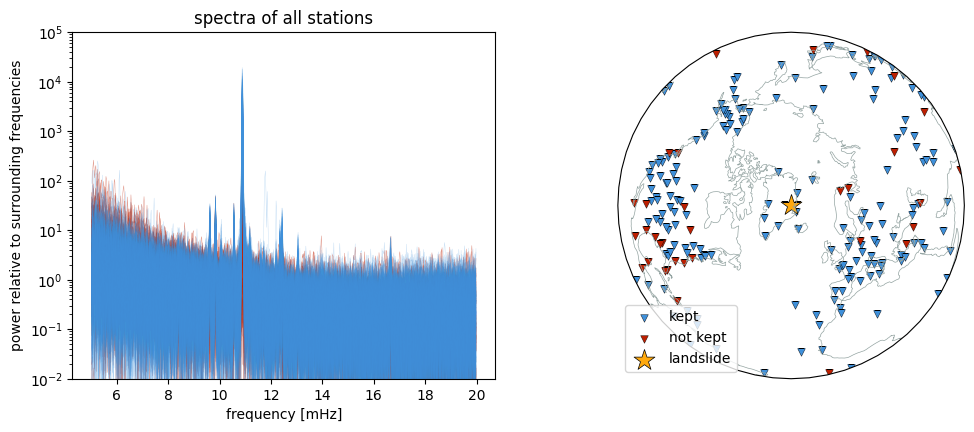

In [2]:
freqs = np.fft.rfftfreq(n_samples, 1 / sampling_rate)
power = np.abs(np.fft.rfft(waveforms * np.hanning(n_samples), axis=1)) ** 2
at_peak = (freqs > 10.6e-3) & (freqs < 11.2e-3)
around = ((freqs > 8e-3) & (freqs < 10e-3)) | ((freqs > 12e-3) & (freqs < 14e-3))
signal_to_noise = power[:, at_peak].mean(axis=1) / np.maximum(power[:, around].mean(axis=1), 1e-300)
good = signal_to_noise > 10
print(f"{good.sum()} of {len(good)} stations kept")

fig = plt.figure(figsize=(12, 4.5))
ax = fig.add_subplot(1, 2, 1)
shown = (freqs > 5e-3) & (freqs < 20e-3)
normalised = power[:, shown] / power[:, around].mean(axis=1, keepdims=True).clip(1e-300)
ax.plot(freqs[shown] * 1e3, normalised[~good].T, c="#bd1f01", lw=0.3, alpha=0.5)
ax.plot(freqs[shown] * 1e3, normalised[good].T, c="#3f90da", lw=0.3, alpha=0.3)
ax.set(
    yscale="log",
    ylim=(1e-2, 1e5),
    xlabel="frequency [mHz]",
    ylabel="power relative to surrounding frequencies",
)
ax.set_title("spectra of all stations")

ax = fig.add_subplot(1, 2, 2, projection=ccrs.Orthographic(*landslide))
ax.set_global()
ax.coastlines(lw=0.5, color="#94a4a2")
kwargs = dict(transform=ccrs.PlateCarree(), marker="v", s=30, ec="k", lw=0.3)
ax.scatter(station_lon[good], station_lat[good], c="#3f90da", label="kept", **kwargs)
ax.scatter(station_lon[~good], station_lat[~good], c="#bd1f01", label="not kept", **kwargs)
ax.scatter(
    *landslide,
    transform=ccrs.PlateCarree(),
    marker="*",
    s=250,
    c="#ffa90e",
    ec="k",
    lw=0.5,
    label="landslide",
)
ax.legend(loc="lower left")

## 3. Spectra and cross-spectral density matrix

We cut the 12 hours into 2-hour windows and keep the frequencies between 10 and 12 mHz. Seismometers and sites differ, so we give every station the same weight: each spectrum is divided by its mean amplitude. $K$ is averaged over the windows; we leave out the auto-correlations (cross-correlation beamformer).

The function `coherence` is the beamformer of notebook 2, for any table of traveltimes (grid points, stations), divided by the largest possible beampower (notebook 4).

In [3]:
n_window = int(2 * 3600 * sampling_rate)
windows = waveforms[good].reshape(good.sum(), -1, n_window).transpose(1, 0, 2)  # (windows, stations, samples)
windows = windows - windows.mean(axis=-1, keepdims=True)

freqs = np.fft.rfftfreq(n_window, 1 / sampling_rate)
band = (freqs > 10e-3) & (freqs < 12e-3)
spectra = np.fft.rfft(windows * np.hanning(n_window), axis=-1)[:, :, band]
spectra /= np.sqrt(np.mean(np.abs(spectra) ** 2, axis=-1, keepdims=True))
omega = 2 * np.pi * freqs[band]
print(f"spectra: {spectra.shape} (windows, stations, frequencies)")

n_stations = good.sum()
K = np.einsum("mjw, mkw -> wjk", spectra, spectra.conj()) / len(spectra)  # (frequencies, stations, stations)
K[:, np.arange(n_stations), np.arange(n_stations)] = 0


def coherence(traveltimes, sign=1):
    """Coherence for a table of traveltimes (grid points, stations); sign: see section 7."""
    beampower = np.zeros(len(traveltimes))
    for w in range(len(omega)):
        s = sign * np.exp(-1j * omega[w] * traveltimes)  # steering vectors
        beampower += np.sum((s.conj() @ K[w]) * s, axis=1).real  # s^H K s
    return beampower / ((n_stations - 1) * n_stations * len(omega))

spectra: (6, 223, 14) (windows, stations, frequencies)


## 4. Step 1: a constant velocity

The candidate sources are a grid around East Greenland. On the globe, the traveltime is the distance along the great circle, divided by the velocity. We do not know the velocity of the waves, so we search for it too: one beamforming run per velocity.

distances: (2623, 223) (grid points, stations)


Text(0.5, 1.0, 'best velocity: 4.08 km/s')

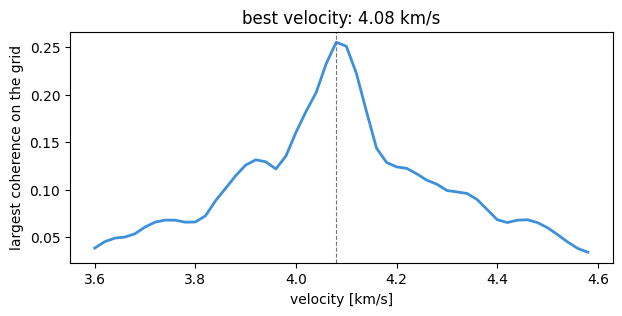

In [4]:
def distance_km(lon1, lat1, lon2, lat2, radius=6371.0):
    """Distance along the great circle, on a sphere (haversine formula)."""
    lon1, lat1, lon2, lat2 = (np.deg2rad(a) for a in (lon1, lat1, lon2, lat2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * radius * np.arcsin(np.sqrt(a))


grid_lon, grid_lat = table["grid_lon"], table["grid_lat"]  # 0.4 x 0.2 degrees, about 14 x 22 km
distances = distance_km(
    grid_lon[:, None], grid_lat[:, None], station_lon[None, good], station_lat[None, good]
)
print(f"distances: {distances.shape} (grid points, stations)")

velocities = np.arange(3.6, 4.6, 0.02)  # km/s
coherence_velocities = np.array([coherence(distances / velocity) for velocity in velocities])
best = coherence_velocities.max(axis=1).argmax()
coherence_constant = coherence_velocities[best]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(velocities, coherence_velocities.max(axis=1), c="#3f90da", lw=2)
ax.axvline(velocities[best], c="#717581", lw=0.8, ls="--")
ax.set(xlabel="velocity [km/s]", ylabel="largest coherence on the grid")
ax.set_title(f"best velocity: {velocities[best]:.2f} km/s")

## 5. Step 2: traveltimes from a velocity model

The Earth is not uniform: Rayleigh waves of this period travel faster under old continents and slower under young oceans, by a few percent. `greenland_traveltimes.npz` holds traveltimes through a global map of Rayleigh-wave phase velocities, from every grid point to every station, computed with the fast marching method. For beamforming, nothing changes but the table:

In [5]:
traveltimes = table["traveltimes"][:, good]
print(f"traveltimes: {traveltimes.shape} (grid points, stations)")
coherence_model = coherence(traveltimes)

traveltimes: (2623, 223) (grid points, stations)


## 6. Results

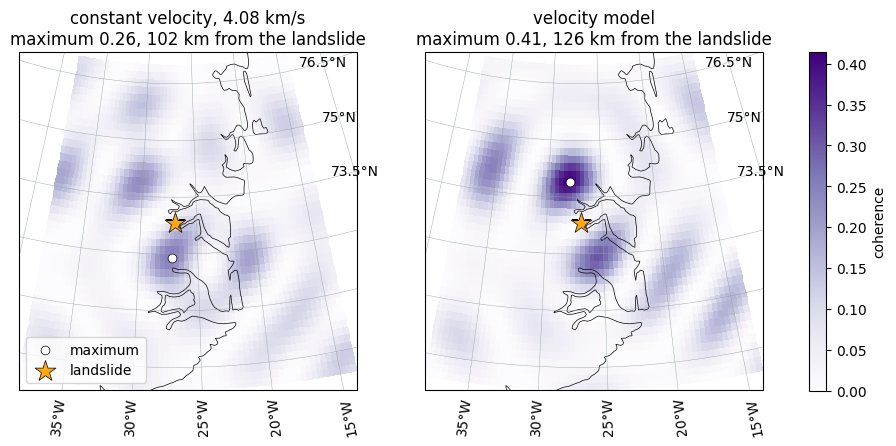

In [6]:
def plot_maps(results):
    n_lat, n_lon = len(np.unique(grid_lat)), len(np.unique(grid_lon))
    projection = ccrs.Stereographic(central_longitude=landslide[0], central_latitude=landslide[1])
    fig, axs = plt.subplots(1, 2, figsize=(12, 5.5), subplot_kw={"projection": projection})
    vmax = max(values.max() for values in results.values())
    for ax, (title, values) in zip(axs, results.items()):
        pcm = ax.pcolormesh(
            grid_lon.reshape(n_lat, n_lon), grid_lat.reshape(n_lat, n_lon), values.reshape(n_lat, n_lon),
            transform=ccrs.PlateCarree(), cmap="Purples", vmin=0, vmax=vmax,
        )  # fmt: skip
        ax.coastlines("50m", lw=0.5)
        ax.gridlines(draw_labels=["bottom", "left"], lw=0.3, color="#94a4a2")
        peak = values.argmax()
        off = distance_km(grid_lon[peak], grid_lat[peak], *landslide)
        kwargs = dict(transform=ccrs.PlateCarree(), ec="k", lw=0.5)
        ax.scatter(grid_lon[peak], grid_lat[peak], marker="o", s=40, c="w", label="maximum", **kwargs)
        ax.scatter(*landslide, marker="*", s=250, c="#ffa90e", label="landslide", **kwargs)
        ax.set_title(f"{title}\nmaximum {values.max():.2f}, {off:.0f} km from the landslide")
    axs[0].legend(loc="lower left")
    fig.colorbar(pcm, ax=axs, label="coherence", shrink=0.8)


plot_maps({
    f"constant velocity, {velocities[best]:.2f} km/s": coherence_constant,
    "velocity model": coherence_model,
})  # fmt: skip

With a constant velocity, the recordings fit best at 4.08 km/s, a typical velocity of Rayleigh waves of this period. The velocity model fits them much better: the coherence rises from 0.26 to 0.41. But both maps show the same pattern: two maxima, about 100 km north and south of the landslide, and little coherence at the landslide itself.

## 7. The source is a horizontal force

So far, the steering vectors assume a source that sends the same wave in all directions. Water that sloshes back and forth pushes the Earth sideways: a horizontal force. Its Rayleigh waves leave with opposite sign in opposite directions. A steering vector can hold more than a traveltime: here, we flip its sign for the stations on one side of the candidate source. That is one sign per grid point and station, which our function takes as `sign`. We search for the direction of the force.

best direction of the force: 170° from north


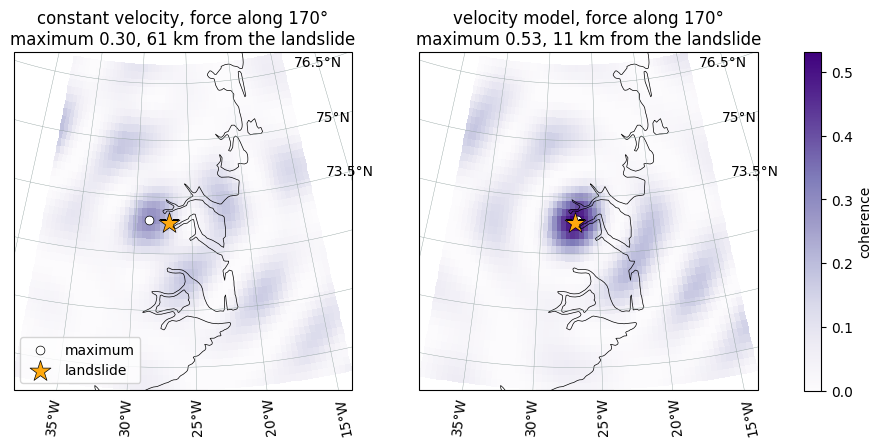

In [7]:
def azimuth(lon1, lat1, lon2, lat2):
    """Direction from point 1 to point 2, clockwise from north, in radians."""
    lon1, lat1, lon2, lat2 = (np.deg2rad(a) for a in (lon1, lat1, lon2, lat2))
    east = np.sin(lon2 - lon1) * np.cos(lat2)
    north = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(lon2 - lon1)
    return np.arctan2(east, north)


azimuths = azimuth(grid_lon[:, None], grid_lat[:, None], station_lon[None, good], station_lat[None, good])


def coherence_force(traveltimes, force_azimuth):
    """Coherence for a horizontal force: the steering vectors change sign with direction."""
    return coherence(traveltimes, sign=np.sign(np.cos(azimuths - np.deg2rad(force_azimuth))))


force_azimuths = np.arange(0, 180, 10)  # degrees from north
largest = [coherence_force(traveltimes, force_azimuth).max() for force_azimuth in force_azimuths]
best_force = force_azimuths[np.argmax(largest)]
print(f"best direction of the force: {best_force}° from north")

plot_maps({
    f"constant velocity, force along {best_force}°": coherence_force(distances / velocities[best], best_force),
    f"velocity model, force along {best_force}°": coherence_force(traveltimes, best_force),
})  # fmt: skip

With a force along 170° (N10°W–S10°E), the map of the velocity model has a single maximum, 11 km from the landslide (less than a grid cell), with a coherence of 0.53. With the constant velocity, the maximum is 61 km away, with a coherence of 0.30.

> **The direction matches the paper and the fjord.** From the radiation pattern on three-component recordings, Svennevig et al. (2024) find Rayleigh waves radiated along 160°, perpendicular to the axis of Dickson Fjord (070°), and Love waves along the fjord: a force across the fjord, as expected for water sloshing between its walls. Our search in steps of 10°, with vertical components only, gives 170°.
 The wavelength is about 375 km: the velocity model matters, even for a location within a fraction of a wavelength.

## 8. For your own data

- **Recordings**: change the stations, times and data centres in `download_greenland.py`, and the frequency band and windows in section 3.
- **Start with a constant velocity** (section 4). It needs nothing but coordinates, and tells you whether there is a source to find.
- **Traveltimes from a model**: `greenland_traveltimes.py` shows how the table used here was computed, with the fast marching method ([pykonal](https://github.com/malcolmw/pykonal), `uv sync --extra fmm`) through the Rayleigh-wave phase-velocity maps of LITHO1.0 (Pasyanos et al., 2014). Every case needs its own table: another model, in 2D or 3D, ray tracing or a wave simulation instead of fast marching. For beamforming, only the table (grid points, stations) matters.
- **Over time**: compute $K$ for each window instead of their average, for one map per window (as in notebook 5).

*Pasyanos, M. E., Masters, T. G., Laske, G. & Ma, Z., 2014. LITHO1.0: An updated crust and lithospheric model of the Earth. J. Geophys. Res. Solid Earth, 119, 2153–2173. doi:10.1002/2013JB010626*